# **Figure 5**

Reproduces panels **?**–**?** of Figure 5 and Supplementary Tables ?–? from simulation data. Data used:
- `DNb08_Stim/hyak/run_id=28357516` (**a–b**, **i**)
- `DNb08_Stim_FANC/default/run_id=2026040701` (**b**)
- `DNb08_Stim_IMAC_vncOnly/default/run_id=2026040200` (**b**)
- `DNb08_Stim_BANC_vncOnly/default/run_id=2026040700` (**b**)
- `DNb08_Stim_Prune/hyak/run_id=28961813` (**f**)
- `DNb08_Stim_Prune_FANC/default/run_id=2026040900` (**g**)
- `DNb08_Stim_Silence/hyak/run_id=28907523`(**i**)
- `DNb08_Stim_Silence/hyak/run_id=28881642` (**i**)
- `DNb08_Stim_FANC/default/run_id=2026041000` (**i**)
- `DNb08_Stim_FANC/default/run_id=2026041001` (**i**)

In [ ]:
dataPath = "/data/users/smpuglie/published-simulations/"

In [ ]:
import matplotlib.pyplot as plt
from src.utils.plot_utils import *
from src.utils.sim_utils import *
import yaml
import numpy as np
import jax.numpy as jnp
import sparse
from hydra import initialize, compose
from hydra.core.hydra_config import HydraConfig
from omegaconf import DictConfig, OmegaConf
from pathlib import Path, PosixPath
import h5py

os.environ['CUDA_VISIBLE_DEVICES'] = '0' # Specify which GPU to use

# # PLOT defaults
plt.rcParams["font.sans-serif"] = "Arial"
plt.rcParams["axes.spines.right"] = "False"
plt.rcParams["axes.spines.top"] = "False"
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["figure.figsize"] = (2,2)
plt.rcParams['axes.linewidth'] = 0.25
plt.rcParams["xtick.major.size"] = 1.7
plt.rcParams["xtick.minor.size"] = 1.0
plt.rcParams["ytick.major.size"] = 1.7
plt.rcParams["xtick.major.width"] = 0.25
plt.rcParams["xtick.minor.width"] = 0.18
plt.rcParams["ytick.major.width"] = 0.25
plt.rcParams["figure.dpi"] = 200

plt.rcParams["axes.labelpad"] = 1.5
plt.rcParams["xtick.major.pad"] = 1.5
plt.rcParams["ytick.major.pad"] = 1.5

SMALL_SIZE = 6
LABEL_SIZE = 7
AXLABEL_SIZE = 8
TITLE_SIZE = 10

plt.rcParams["font.family"] = "Arial" # "Arial"
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=AXLABEL_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=LABEL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=TITLE_SIZE)  # fontsize of the figure title

moduleColors = get_module_colors()

dnColor = "#51bbad"
excColor = "#d84a2e"
inhColor = "#026b85"
mnColor = "#267655"

lightDnColor = "#a7dcd5ff"
lightExcColor = "#ff9985"

from seaborn.external import husl
def make_palette(color):
    hue = husl.hex_to_husl(color)[0]
    return sns.blend_palette(["white",husl.husl_to_rgb(hue,45,80),color,husl.husl_to_rgb(hue,65,35)],as_cmap=True)

Using diffeqsolve-based neural simulation (original)


# MANC 1024x DNb08 activation

In [ ]:
simType = "DNb08_Stim"
simPath = simType+"/hyak/run_id=28357516"
folder = dataPath + simPath
Rs = sparse.load_npz(folder+f"/ckpt/{simType}_Rs.npz").todense()
params = DictConfig(load_from_yaml(folder+"/logs/run_config.yaml"))

dataset = 0
Rs = Rs[dataset]
nSims = Rs.shape[0]
Rs.shape

In [ ]:
wTable = pd.read_csv("../"+params.experiment["dfPath"].split("Pugliese_2025")[1])
mnData = sort_motor_modules(wTable.loc[wTable["motor module"].notna()])
nMnsActive = pd.Series(index=np.arange(nSims))
nMnsActiveTinyThreshold = pd.Series(index=np.arange(nSims))
simScore = pd.Series(index=np.arange(nSims))

for i in range(nSims):
    # active neurons
    R = Rs[i]
    
    activeMnsMask = (np.max(R,1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
    nMnsActive.loc[i] = np.sum(activeMnsMask)
    activeMnsMaskPastTransient = (np.max(R[:,250:],1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
    score, _ = compute_oscillation_score(R[...,250:],activeMnsMaskPastTransient)
    nMnsActiveTinyThreshold.loc[i] = np.sum(activeMnsMaskPastTransient)
    simScore.loc[i] = score

figFolder = "../figures/"
figFolder += "-".join(str.split(simPath,"/"))

/home/smpuglie/vnc-connectome-sim/src/utils/plot_utils.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neuronData[colName] = pd.Categorical(neuronData[colName],categories=["coxa swing", "coxa stance", "femur/tr extend", "femur/tr flex",


### individual traces

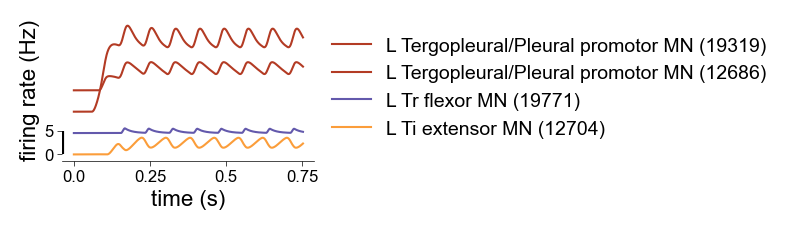

In [5]:
idx = 552 #np.random.randint(nSims)
spacer = 4.5
scalebar = 5

timeLimit = .75

R = Rs[idx]

plt.figure()
ax = plot_R_traces_stacked_by_module(R[:,:750],mnData,activeOnly=True,space=spacer)# ,colorMapper=colorMapper)
add_tAxis(ax,timeLimit,3.00001)
xlimits = ax.get_xlim()
plt.vlines(xlimits[0],0,scalebar,"k")
plt.yticks([0,scalebar])
plt.xlim(xlimits)
ax.spines[["left","top","right"]].set_visible(False)
fig = plt.gcf()
ax.grid(False)
plt.xlabel("time (s)")


fig.set_figwidth(1.626)
fig.set_figheight(1.226*3/4)
# fig.set_dpi(500)

# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# plt.savefig(figFolder+f"/mnTraces_idx{idx}.svg",transparent=True)
plt.show()

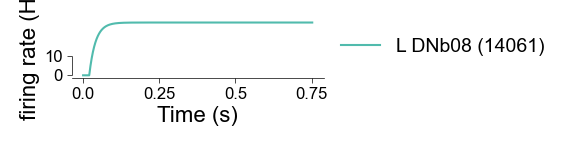

In [6]:
idx = 552 # np.random.randint(1000)
R = Rs[idx]
spacer=10

tIdxs = np.arange(0,1000)

dnb08data = wTable.loc[wTable["type"]=="DNb08"].copy()
dnb08data["somaSide"] = ["LHS","LHS","RHS","RHS"]

plt.figure()
ax = plot_R_traces_stacked_2(R[:,:750],dnb08data,activeOnly=True,space=spacer,colors=["#51bbad"])# ,colorMapper=colorMapper)
add_tAxis(ax,0.75,3.0001)
xlimits = ax.get_xlim()
plt.vlines(xlimits[0],0,10,"k",linewidth=0.25)
plt.yticks([0,10])
plt.xlim(xlimits)
ax.spines[["left","top","right"]].set_visible(False)
ax.grid(False)
plt.ylabel("firing rate (Hz)")
fig = plt.gcf()

fig.set_figwidth(1.626)
fig.set_figheight(0.377)

# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# plt.savefig(figFolder+f"/dnb08trace_idx{idx}.svg",transparent=True)
plt.show()

# DNb08 activation in all four datasets

## load for the first time

In [2]:
simType = "DNb08_Stim"
figFolder = "../figures/"
figFolder += f"{simType}-combined"

simPath = simType+"/hyak/run_id=28357516"
folder = dataPath + simPath
# stays sparse: .todense() here allocates 37.7 GB on top of the coords, which
# OOM-kills the kernel. Densify one simulation at a time in the loop below.
Rs = load_Rs_npz(folder+f"/ckpt/{simType}_Rs.npz")
params = DictConfig(load_from_yaml(folder+"/logs/run_config.yaml"))

dataset = 0
nSims = Rs.shape[1]

wTable = pd.read_csv("../"+params.experiment["dfPath"].split("Pugliese_2025")[1])
mnData = sort_motor_modules(wTable.loc[wTable["motor module"].notna()])
nMnsActive_manc = pd.Series(index=np.arange(nSims))
simScore_manc = pd.Series(index=np.arange(nSims))

for i in range(nSims):
    # active neurons
    R = Rs[dataset,i].todense()
    
    activeMnsMask = (np.max(R,1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
    nMnsActive_manc.loc[i] = np.sum(activeMnsMask)
    activeMnsMaskPastTransient = (np.max(R[:,250:],1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
    score, _ = compute_oscillation_score(R[...,250:],activeMnsMaskPastTransient)
    simScore_manc.loc[i] = score

/home/smpuglie/vnc-connectome-sim/src/utils/plot_utils.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neuronData[colName] = pd.Categorical(neuronData[colName],categories=["coxa swing", "coxa stance", "femur/tr extend", "femur/tr flex",


In [4]:
simType = "DNb08_Stim_FANC"

simPath = simType+"/default/run_id=2026040701"
folder = dataPath + simPath
# kept sparse, densified one simulation at a time -- see the MANC cell above
Rs = load_Rs_npz(folder+f"/ckpt/{simType}_Rs.npz")
params = DictConfig(load_from_yaml(folder+"/logs/run_config.yaml"))

dataset = 0
nSims = Rs.shape[1]

wTable = pd.read_csv("../"+params.experiment["dfPath"].split("vnc-connectome-sim")[1])
mnData = sort_motor_modules(wTable.loc[wTable["motor module"].notna()])
nMnsActive_fanc = pd.Series(index=np.arange(nSims))
simScore_fanc = pd.Series(index=np.arange(nSims))

for i in range(nSims):
    # active neurons
    R = Rs[dataset,i].todense()
    
    activeMnsMask = (np.max(R,1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
    nMnsActive_fanc.loc[i] = np.sum(activeMnsMask)
    activeMnsMaskPastTransient = (np.max(R[:,250:],1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
    score, _ = compute_oscillation_score(R[...,250:],activeMnsMaskPastTransient)
    simScore_fanc.loc[i] = score

/home/smpuglie/vnc-connectome-sim/src/utils/plot_utils.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neuronData[colName] = pd.Categorical(neuronData[colName],categories=["coxa swing", "coxa stance", "femur/tr extend", "femur/tr flex",


In [5]:
simType = "DNb08_Stim_IMAC_vncOnly"
simPath = simType+"/default/run_id=2026040200"
folder = dataPath + simPath
subfolders = []
for f in os.listdir(folder):
    if os.path.isdir(f"{folder}/{f}") and ("experiment.seed" in f):
        subfolders.append(f)

dataset = 0
# concatenate the runs while they are still sparse: np.concatenate holds the old
# block, the new block and the result at once, which peaks well past 50 GB here
# and gets the kernel OOM-killed
parts = []
for subfolder in subfolders:
    print(subfolder)
    parts.append(load_Rs_npz(folder+f"/{subfolder}/ckpt/{simType}_Rs.npz")[dataset])
Rs = sparse.concatenate(parts, axis=0)

params = DictConfig(load_from_yaml(folder+"/multirun.yaml"))

nSims = Rs.shape[0]
Rs.shape
wTable = pd.read_csv("../"+params.experiment["dfPath"].split("vnc-connectome-sim")[1])
mnData = sort_motor_modules(wTable.loc[wTable["motor module"].notna()])
nMnsActive_imac = pd.Series(index=np.arange(nSims))
simScore_imac = pd.Series(index=np.arange(nSims))

for i in range(nSims):
    # active neurons
    R = Rs[i].todense()
    
    activeMnsMask = (np.max(R,1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
    nMnsActive_imac.loc[i] = np.sum(activeMnsMask)
    activeMnsMaskPastTransient = (np.max(R[:,250:],1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
    score, _ = compute_oscillation_score(R[...,250:],activeMnsMaskPastTransient)
    simScore_imac.loc[i] = score

experiment.seed=460
experiment.seed=17


/home/smpuglie/vnc-connectome-sim/src/utils/plot_utils.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neuronData[colName] = pd.Categorical(neuronData[colName],categories=["coxa swing", "coxa stance", "femur/tr extend", "femur/tr flex",


In [6]:
simType = "DNb08_Stim_BANC_vncOnly"
simPath = simType+"/default/run_id=2026040700"
folder = dataPath + simPath
subfolders = []
for f in os.listdir(folder):
    if os.path.isdir(f"{folder}/{f}") and ("experiment.seed" in f):
        subfolders.append(f)

dataset = 0
# concatenate the runs while they are still sparse: np.concatenate holds the old
# block, the new block and the result at once, which peaks well past 50 GB here
# and gets the kernel OOM-killed
parts = []
for subfolder in subfolders:
    print(subfolder)
    parts.append(load_Rs_npz(folder+f"/{subfolder}/ckpt/{simType}_Rs.npz")[dataset])
Rs = sparse.concatenate(parts, axis=0)

params = DictConfig(load_from_yaml(folder+"/multirun.yaml"))

nSims = Rs.shape[0]
Rs.shape
wTable = pd.read_csv("../"+params.experiment["dfPath"].split("vnc-connectome-sim")[1])
mnData = sort_motor_modules(wTable.loc[wTable["motor module"].notna()])
nMnsActive_banc = pd.Series(index=np.arange(nSims))
simScore_banc = pd.Series(index=np.arange(nSims))

for i in range(nSims):
    # active neurons
    R = Rs[i].todense()
    
    activeMnsMask = (np.max(R,1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
    nMnsActive_banc.loc[i] = np.sum(activeMnsMask)
    activeMnsMaskPastTransient = (np.max(R[:,250:],1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
    score, _ = compute_oscillation_score(R[...,250:],activeMnsMaskPastTransient)
    simScore_banc.loc[i] = score

experiment.seed=220
experiment.seed=341


/home/smpuglie/vnc-connectome-sim/src/utils/plot_utils.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neuronData[colName] = pd.Categorical(neuronData[colName],categories=["coxa swing", "coxa stance", "femur/tr extend", "femur/tr flex",


In [7]:
nMnsActive_combined = pd.concat([nMnsActive_manc,
                                 nMnsActive_fanc,
                                 nMnsActive_imac,
                                 nMnsActive_banc],axis=1).rename(columns=dict(zip(np.arange(4),["MANC","FANC","mCNS","BANC"])))

simScore_combined = pd.concat([simScore_manc,
                                 simScore_fanc,
                                 simScore_imac,
                                 simScore_banc],axis=1).rename(columns=dict(zip(np.arange(4),["MANC","FANC","mCNS","BANC"])))

figFolder = "../figures/"
figFolder += "DNb08_Stim-combinedDatasets"

# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# nActive_combined.to_csv(figFolder+"/nActive.csv")
# nMnsActive_combined.to_csv(figFolder+"/nMnsActive.csv")
# simScore_combined.to_csv(figFolder+"/scores.csv")

## reload and plot data

In [3]:
figFolder = "../figures/"
figFolder += "DNb08_Stim-combinedDatasets"

nMnsActive_combined = pd.read_csv(figFolder+"/nMnsActive.csv",index_col=0)
simScore_combined = pd.read_csv(figFolder+"/scores.csv",index_col=0)

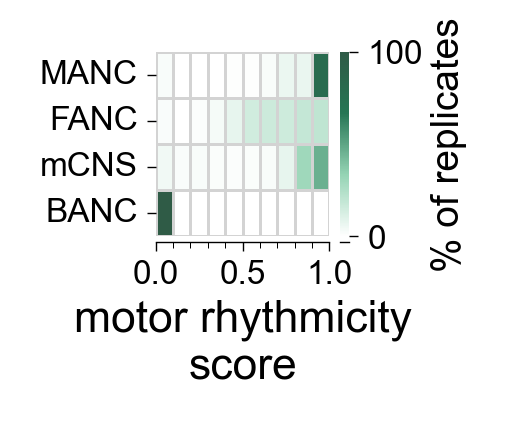

In [8]:
nSims = len(simScore_combined)
histBins = np.linspace(0,np.max(simScore_combined),11)
histBinCenters = (histBins[:-1] + histBins[1:]) / 2
scoreHistDf = pd.DataFrame(index=histBinCenters,columns = simScore_combined.columns)
for col in simScore_combined.columns:
    scoreHistDf[col] = 100*(np.histogram(simScore_combined[col],bins=histBins)[0] / nSims)

xmax = 1.05
nBinsPlotted = len(scoreHistDf[:xmax])
xticklabels = np.round(histBins[np.arange(0,nBinsPlotted+1)],1).astype(str).tolist()
for i in range(len(xticklabels)):
    if i % 5 !=0:
        xticklabels[i]=""

plt.figure(figsize=(0.7,0.6))

ax = sns.heatmap(scoreHistDf[:xmax].transpose(),cmap=make_palette(mnColor),cbar=True,yticklabels=True,cbar_kws={"ticks":[0,100]},vmax=100,linecolor="lightgray",linewidths=0.5)
cbar = ax.collections[0].colorbar
cbar.set_label("% of replicates",fontsize=7)
sns.despine(offset={"left":2,"bottom":1},left=True)
# ax.set_xticks(np.arange(0,nBinsPlotted+1),xticklabels,rotation=0)

ax.set_xticks(np.arange(0,nBinsPlotted+1,5),np.round(histBins[np.arange(0,nBinsPlotted+1,5)],1))
ax.set_xticks(np.arange(0,nBinsPlotted+1),minor=True)
# ax.grid()
plt.gcf().set_dpi(400)
plt.xlabel("motor rhythmicity\nscore")

# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# plt.savefig(figFolder+"/mnScoreStackedHeatmaps_v2.svg",transparent=True)
plt.show()

/tmp/ipykernel_862636/3503458384.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  scoreHistDf.fillna(0,inplace=True)


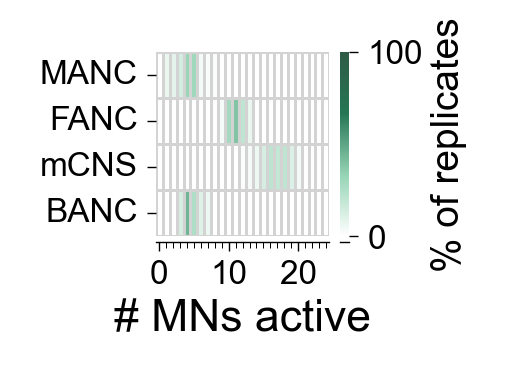

In [9]:
nMnsActive = nMnsActive_combined.astype(int)
nMnsActiveCounts = nMnsActive.apply(pd.Series.value_counts).fillna(0)
histBins = np.arange(200)
scoreHistDf = pd.DataFrame(index=histBins,columns = nMnsActive.columns)
scoreHistDf.loc[nMnsActiveCounts.index] = nMnsActiveCounts
scoreHistDf.fillna(0,inplace=True)

scoreHistDf = scoreHistDf*100/nSims

xmax = 25
nBinsPlotted = len(scoreHistDf[:xmax])
xticklabels = np.round(histBins[np.arange(0,nBinsPlotted+1)],1).astype(str).tolist()
for i in range(len(xticklabels)):
    if i % 5 !=0:
        xticklabels[i]=""

plt.figure(figsize=(0.7,0.6))


ax = sns.heatmap(scoreHistDf[:xmax].transpose(),cmap=make_palette(mnColor),cbar_kws={"ticks":[0,100]},cbar=True,vmin=0,vmax=100,yticklabels=True,linecolor="lightgray",linewidths=0.25)
cbar = ax.collections[0].colorbar
cbar.set_label("% of replicates",fontsize=7)
sns.despine(offset={"left":2,"bottom":1},left=True)
# ax.set_xticks(np.arange(0,nBinsPlotted+1),xticklabels,rotation=

sns.despine(offset={"left":2,"bottom":1},left=True)
# ax.set_xticks(np.arange(0,nBinsPlotted+1,2),np.round(histBins[np.arange(0,nBinsPlotted+1,2)],1),rotation=45)
ax.set_xticks(np.arange(0.5,nBinsPlotted+.5,10),np.round(histBins[np.arange(0,nBinsPlotted+1,10)],1))
ax.set_xticks(np.arange(0.5,nBinsPlotted+.5,1),minor=True)
plt.gcf().set_dpi(400)
plt.xlabel("# MNs active")


# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# plt.savefig(figFolder+"/activeMnStackedHeatmaps_test.svg",transparent=True)

plt.show()

In [10]:
nMnsActive.max(0)

MANC    14
FANC    15
mCNS    23
BANC     8
dtype: int64

# MANC 1024x DNb08 pruning

In [7]:
simType = "DNb08_Stim_Prune"
simPath = simType+"/hyak/run_id=28961813"
folder = dataPath + simPath
minicircuits = sparse.load_npz(folder+f"/ckpt/{simType}_mini_circuits.npz").todense()
params = DictConfig(load_from_yaml(folder+"/logs/run_config.yaml"))

nRuns = minicircuits.shape[0]

wTable = pd.read_csv("../"+params.experiment["dfPath"].split("Pugliese_2025")[1])
mnData = sort_motor_modules(wTable.loc[wTable["motor module"].notna()])

/home/smpuglie/vnc-connectome-sim/src/utils/plot_utils.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neuronData[colName] = pd.Categorical(neuronData[colName],categories=["coxa swing", "coxa stance", "femur/tr extend", "femur/tr flex",


In [8]:
minicircuitsDf = pd.DataFrame(data=minicircuits,columns = wTable.bodyId)
minicircuitsDf = minicircuitsDf.iloc[:,np.argsort(np.sum(minicircuitsDf.values, 0))]
minicircuitsDf[14061] = False #exclude DNb08
minicircuitsDf[wTable.loc[mnData.index,"bodyId"]] = False # exclude MNs...

figFolder = "../figures/"
figFolder += "-".join(str.split(simPath,"/"))

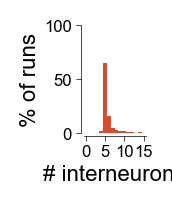

In [9]:
ax = sns.histplot(minicircuitsDf.sum(1),color=excColor,bins=np.arange(90),edgecolor=None,stat="percent",alpha=1,discrete=True)
# ax.set_xlim(0,30)
# plt.yticks(np.arange(0,20,4))
ax.set_xlabel("# interneurons")
ax.set_ylabel("% of runs")
ax.set_xticks(np.arange(0,40,5))
# ax.set_xticks(np.arange(0,40,1),minor=True,)
ax.set_xlim(-0.5,15.5)
ax.tick_params(axis='both', which='major')
ax.spines[["top","right"]].set_visible(False)

plt.ylim([0,100])

fig = plt.gcf()
fig.set_figheight(0.7)
# fig.set_figwidth(1.0)
fig.set_figwidth(0.4)
# plt.gcf().set_dpi(400)
sns.despine(offset=1)

# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# plt.savefig(figFolder+"/minicircuitNIns_skinny.svg",transparent=True)
plt.show()

In [10]:
orderedInPrevalences = minicircuitsDf.transpose().sum(1).sort_values(ascending=False)
orderedInPcts = orderedInPrevalences / nRuns * 100
orderedInNts = orderedInPcts.index.map(dict(zip(wTable["bodyId"],wTable["predictedNt"])))
orderedInTypes = orderedInPcts.index.map(dict(zip(wTable["bodyId"],wTable["type"])))
ntColors = {"acetylcholine":excColor,"gaba":inhColor,"glutamate":inhColor}
orderedColors = orderedInNts.map(ntColors)

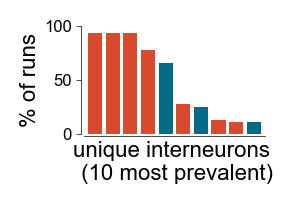

In [11]:
fig = plt.figure()
ax = orderedInPcts[:10].plot.bar(color=orderedColors[:10],width=0.8,rot=90)
plt.xticks([])
plt.ylabel("% of runs")
plt.xlabel("unique interneurons \n (10 most prevalent)")

plt.ylim([0,100])

ax.spines[["top","right"]].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=6)
fig.set_figheight(0.7)
fig.set_figwidth(1.172)
# fig.set_dpi(400)

sns.despine(offset=1)

# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# plt.savefig(figFolder+"/minicircuitUniqueIns.svg",transparent=True)
plt.show()

## Distinct converged circuits (Supplementary Table 7)

In [12]:
pd.options.display.max_colwidth = None

def bodyIdToIdx(wTable,bodyIdList):
    return wTable[wTable["bodyId"].isin(bodyIdList)].index.to_numpy().astype(int)

distinctCircuits = pd.Series()
for idx in minicircuitsDf.index:
    tmp = minicircuitsDf.loc[idx]
    distinctCircuits.loc[idx] = sorted(tmp[tmp].index.to_list())
commonCircuits = pd.DataFrame(distinctCircuits.value_counts())[pd.DataFrame(distinctCircuits.value_counts())>=10].dropna().astype(int)
commonCircuits.insert(0,"types",[""]*len(commonCircuits))

for i in range(len(commonCircuits)):
    commonCircuits["types"].iloc[i] = str(wTable.loc[bodyIdToIdx(wTable,commonCircuits.index[i]),"type"].tolist())
commonCircuits.index = commonCircuits.index.astype(str)
display(commonCircuits)
# print(commonCircuits.to_latex(index=True))

/tmp/ipykernel_3957012/116839132.py:14: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  commonCircuits["types"].iloc[i] = str(wTable.loc[bodyIdToIdx(wTable,commonCircuits.index[i]),"type"].tolist())
/tmp/ipykernel_3957012/116839132.py:14: Sett

,types,count
"[10242, 10707, 11751, 12021, 162543]","['IN19A007', 'IN17A001', 'INXXX466', 'IN03A006', 'INXXX464']",465
"[10715, 11751, 12021, 13905, 162543]","['IN19B012', 'INXXX466', 'IN03A006', 'IN16B036', 'INXXX464']",129
"[10707, 11751, 12021, 13905, 17664, 162543]","['IN17A001', 'INXXX466', 'IN03A006', 'IN16B036', 'MNfl10', 'INXXX464']",26
"[10707, 11751, 12021, 13905, 162539, 162543]","['IN17A001', 'INXXX466', 'IN03A006', 'IN16B036', 'IN13A001', 'INXXX464']",21
"[10707, 11751, 12021, 13905, 162543]","['IN17A001', 'INXXX466', 'IN03A006', 'IN16B036', 'INXXX464']",12
"[10242, 10707, 11751, 21162, 162543]","['IN19A007', 'IN17A001', 'INXXX466', 'IN20A.22A036', 'INXXX464']",12
"[10242, 10707, 11751, 12021, 21162, 162543]","['IN19A007', 'IN17A001', 'INXXX466', 'IN03A006', 'IN20A.22A036', 'INXXX464']",10


# FANC 1024x DNb08 pruning

In [ ]:
simType = "DNb08_Stim_Prune_FANC"
simPath = simType+"/default/run_id=2026040900"
folder = dataPath + simPath
minicircuits = sparse.load_npz(folder+f"/ckpt/{simType}_mini_circuits.npz").todense()
params = DictConfig(load_from_yaml(folder+"/logs/run_config.yaml"))

nRuns = minicircuits.shape[0]

try:
    wTable = pd.read_csv(".."+params.experiment["dfPath"].split("vnc-connectome-sim")[1])
except:
    wTable = pd.read_csv(".."+params.experiment["dfPath"].split("vnc-connectome-sim")[1].replace('t1 ','t1l ')) # folder name discrepancy....
mnData = sort_motor_modules(wTable.loc[wTable["motor module"].notna()])

/home/smpuglie/vnc-connectome-sim/src/utils/plot_utils.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neuronData[colName] = pd.Categorical(neuronData[colName],categories=["coxa swing", "coxa stance", "femur/tr extend", "femur/tr flex",


In [5]:
minicircuitsDf = pd.DataFrame(data=minicircuits,columns = wTable.pt_supervoxel_id)
minicircuitsDf = minicircuitsDf.iloc[:,np.argsort(np.sum(minicircuitsDf.values, 0))]
minicircuitsDf[[73115599907537415,73256337395801932,73256337395819525]] = False #exclude DNg100 and DNb08s
minicircuitsDf[wTable.loc[mnData.index,"pt_supervoxel_id"]] = False # exclude MNs...

figFolder = "../figures/"
figFolder += "-".join(str.split(simPath,"/"))

In [6]:
sum(minicircuitsDf.sum(1)>15)

54

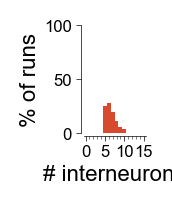

In [7]:
ax = sns.histplot(minicircuitsDf.sum(1),color=excColor,bins=np.arange(90),edgecolor=None,stat="percent",alpha=1,discrete=True)
# ax.set_xlim(0,30)
# plt.yticks(np.arange(0,20,4))
ax.set_xlabel("# interneurons")
ax.set_ylabel("% of runs")
ax.set_xticks(np.arange(0,16,5))
ax.set_xticks(np.arange(0,16,1),minor=True,)
ax.set_xlim(-0.5,15.5)
ax.tick_params(axis='both', which='major')
ax.spines[["top","right"]].set_visible(False)

plt.ylim([0,100])

fig = plt.gcf()
fig.set_figheight(0.7)
fig.set_figwidth(0.4)
# plt.gcf().set_dpi(400)
sns.despine(offset=1)

# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# plt.savefig(figFolder+"/minicircuitNIns_skinny.svg",transparent=True)
plt.show()

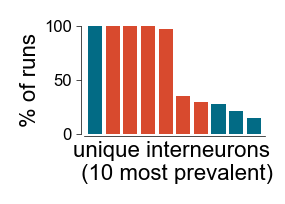

In [8]:
orderedInPrevalences = minicircuitsDf.transpose().sum(1).sort_values(ascending=False)
orderedInPcts = orderedInPrevalences / nRuns * 100
orderedInSigns = orderedInPcts.index.map(dict(zip(wTable["pt_supervoxel_id"],wTable["sign"])))
orderedInTypes = orderedInPcts.index.map(dict(zip(wTable["pt_supervoxel_id"],wTable["w_type"])))
signColors = {1:excColor,-1:inhColor}
orderedColors = orderedInSigns.map(signColors)

fig = plt.figure()
ax = orderedInPcts[:10].plot.bar(color=orderedColors[:10],width=0.8,rot=90)
plt.xticks([])
plt.ylabel("% of runs")
plt.xlabel("unique interneurons \n (10 most prevalent)")

plt.ylim([0,100])

ax.spines[["top","right"]].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=6)
fig.set_figheight(0.7)
fig.set_figwidth(1.172)
# fig.set_dpi(400)

sns.despine(offset=1)
plt.gca().tick_params(axis="x",labelrotation=90)

# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# plt.savefig(figFolder+"/minicircuitUniqueIns.svg",transparent=True)
plt.show()

## Distinct converged circuits (Supplementary Table 8)

In [9]:
pd.options.display.max_colwidth = None

def segIdToIdx(wTable,bodyIdList):
    return wTable.iloc[pd.Index(wTable['pt_supervoxel_id']).get_indexer(bodyIdList)].index.to_numpy().astype(int)

distinctCircuits = pd.Series()
for idx in minicircuitsDf.index:
    tmp = minicircuitsDf.loc[idx]
    distinctCircuits.loc[idx] = sorted(tmp[tmp].index.to_list())
commonCircuits = pd.DataFrame(distinctCircuits.value_counts())[pd.DataFrame(distinctCircuits.value_counts())>=10].dropna().astype(int)
commonCircuits.insert(0,"types",[""]*len(commonCircuits))

for i in range(len(commonCircuits)):
    commonCircuits["types"].iloc[i] = str(wTable.loc[segIdToIdx(wTable,commonCircuits.index[i]),"w_type"].tolist())
commonCircuits.index = commonCircuits.index.astype(str)
display(commonCircuits)
# print(commonCircuits.to_latex(index=True))

/tmp/ipykernel_518409/450656650.py:14: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  commonCircuits["types"].iloc[i] = str(wTable.loc[segIdToIdx(wTable,commonCircuits.index[i]),"w_type"].tolist())
/tmp/ipykernel_518409/450656650.py:14: Setti

,types,count
"[72483380721505294, 72624462142676168, 72834674820722635, 72905112552773752, 72975481296715415]","['19A', '03A', '17A', 'TBD', 'TBD']",246
"[72483380721505294, 72624462142673647, 72624462142676168, 72834674820722635, 72905112552773752, 72975481296715415]","['19A', '03A', '03A', '17A', 'TBD', 'TBD']",84
"[72413150020127131, 72483380721505294, 72624462142676168, 72834674820722635, 72905112552773752, 72975481296715415]","['22A', '19A', '03A', '17A', 'TBD', 'TBD']",76
"[72483380721505294, 72624462142676168, 72834674820722635, 72905112552773752, 72905181339304184, 72975481296715415]","['19A', '03A', '17A', 'TBD', '08A', 'TBD']",46
"[72413150020127131, 72483380721505294, 72624462142676168, 72834674820722635, 72905112552773752, 72905181339304184, 72975481296715415]","['22A', '19A', '03A', '17A', 'TBD', '08A', 'TBD']",25
"[72483380721505294, 72624462142676168, 72834674820722635, 72905112552773752, 72905112619846398, 72975481296715415]","['19A', '03A', '17A', 'TBD', '08A', 'TBD']",25
"[72413150020127131, 72483380721505294, 72624462142673647, 72624462142676168, 72834674820722635, 72905112552773752, 72975481296715415]","['22A', '19A', '03A', '03A', '17A', 'TBD', 'TBD']",24
"[72483380721505294, 72624462142673647, 72624462142676168, 72834674820722635, 72905112552773752, 72905181339304184, 72975481296715415]","['19A', '03A', '03A', '17A', 'TBD', '08A', 'TBD']",22
"[72413150020127131, 72483380721505294, 72624462142676168, 72834674820722635, 72905112552773752, 72905112619846398, 72975481296715415]","['22A', '19A', '03A', '17A', 'TBD', '08A', 'TBD']",12
"[72483380721505294, 72624462142676168, 72834674820722635, 72905112552773752, 72905112619846398, 72905181339304184, 72975481296715415]","['19A', '03A', '17A', 'TBD', '08A', '08A', 'TBD']",11


## Distinct converged circuits (Supplementary Table 7)

In [ ]:
pd.options.display.max_colwidth = None

def bodyIdToIdx(wTable,bodyIdList):
    return wTable[wTable["bodyId"].isin(bodyIdList)].index.to_numpy().astype(int)

distinctCircuits = pd.Series()
for idx in minicircuitsDf.index:
    tmp = minicircuitsDf.loc[idx]
    distinctCircuits.loc[idx] = sorted(tmp[tmp].index.to_list())
commonCircuits = pd.DataFrame(distinctCircuits.value_counts())[pd.DataFrame(distinctCircuits.value_counts())>=10].dropna().astype(int)
commonCircuits.insert(0,"types",[""]*len(commonCircuits))

for i in range(len(commonCircuits)):
    commonCircuits["types"].iloc[i] = str(wTable.loc[bodyIdToIdx(wTable,commonCircuits.index[i]),"type"].tolist())
commonCircuits.index = commonCircuits.index.astype(str)
display(commonCircuits)
# print(commonCircuits.to_latex(index=True))

/tmp/ipykernel_3957012/116839132.py:14: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  commonCircuits["types"].iloc[i] = str(wTable.loc[bodyIdToIdx(wTable,commonCircuits.index[i]),"type"].tolist())
/tmp/ipykernel_3957012/116839132.py:14: Sett

,types,count
"[10242, 10707, 11751, 12021, 162543]","['IN19A007', 'IN17A001', 'INXXX466', 'IN03A006', 'INXXX464']",465
"[10715, 11751, 12021, 13905, 162543]","['IN19B012', 'INXXX466', 'IN03A006', 'IN16B036', 'INXXX464']",129
"[10707, 11751, 12021, 13905, 17664, 162543]","['IN17A001', 'INXXX466', 'IN03A006', 'IN16B036', 'MNfl10', 'INXXX464']",26
"[10707, 11751, 12021, 13905, 162539, 162543]","['IN17A001', 'INXXX466', 'IN03A006', 'IN16B036', 'IN13A001', 'INXXX464']",21
"[10707, 11751, 12021, 13905, 162543]","['IN17A001', 'INXXX466', 'IN03A006', 'IN16B036', 'INXXX464']",12
"[10242, 10707, 11751, 21162, 162543]","['IN19A007', 'IN17A001', 'INXXX466', 'IN20A.22A036', 'INXXX464']",12
"[10242, 10707, 11751, 12021, 21162, 162543]","['IN19A007', 'IN17A001', 'INXXX466', 'IN03A006', 'IN20A.22A036', 'INXXX464']",10


# MANC 1024x DNb08 activation with CPG IN silencing

## load first time

### E1 silencing

In [ ]:
simType = "DNb08_Stim_Silence"
simPath = simType+"/hyak/run_id=28907523"
folder = dataPath + simPath
Rs = sparse.load_npz(folder+f"/ckpt/{simType}_Rs.npz").todense()
params = DictConfig(load_from_yaml(folder+"/logs/run_config.yaml"))

dataset = 0
Rs = Rs[dataset]
nSims = Rs.shape[0]
Rs.shape

wTable = pd.read_csv("../"+params.experiment["dfPath"].split("Pugliese_2025")[1])
mnData = sort_motor_modules(wTable.loc[wTable["motor module"].notna()])
nActive_e1silenced = pd.Series(index=np.arange(nSims))
nMnsActive = pd.Series(index=np.arange(nSims))
simScore = pd.Series(index=np.arange(nSims))

for i in range(nSims):
    R = Rs[i]
    
    nActive_e1silenced.loc[i] = sum(np.max(R,1)>0.01)
    activeMnsMask = (np.max(R,1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
    nMnsActive.loc[i] = np.sum(activeMnsMask)
    activeMnsMaskPastTransient = (np.max(R[:,250:],1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
    score, _ = compute_oscillation_score(R[:,250:],activeMnsMaskPastTransient)
    simScore.loc[i] = score

nMnsActive_e1silenced = nMnsActive.copy()
simScore_e1silenced = simScore.copy()

del R
del Rs
del activeMnsMask
del activeMnsMaskPastTransient

(1024, 4604, 2001)

### E2 silencing

In [3]:
simType = "DNb08_Stim_Silence"
simPath = simType+"/hyak/run_id=28881642/experiment.removeNeurons=[617]"
folder = dataPath + simPath
Rs = sparse.load_npz(folder+f"/ckpt/{simType}_Rs.npz").todense()
params = DictConfig(load_from_yaml(folder+"/logs/run_config.yaml"))

dataset = 0
Rs = Rs[dataset]
nSims = Rs.shape[0]
Rs.shape

(1024, 4604, 2001)

In [ ]:
wTable = pd.read_csv("../"+params.experiment["dfPath"].split("Pugliese_2025")[1])
mnData = sort_motor_modules(wTable.loc[wTable["motor module"].notna()])
nActive_e2silenced = pd.Series(index=np.arange(nSims))
nMnsActive = pd.Series(index=np.arange(nSims))
simScore = pd.Series(index=np.arange(nSims))

for i in range(nSims):
    R = Rs[i]
    
    nActive_e2silenced.loc[i] = sum(np.max(R,1)>0.01)
    activeMnsMask = (np.max(R,1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
    nMnsActive.loc[i] = np.sum(activeMnsMask)
    activeMnsMaskPastTransient = (np.max(R[:,250:],1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
    score, _ = compute_oscillation_score(R[:,250:],activeMnsMaskPastTransient)
    simScore.loc[i] = score

nMnsActive_e2silenced = nMnsActive.copy()
simScore_e2silenced = simScore.copy()

del R
del Rs
del activeMnsMask
del activeMnsMaskPastTransient

/home/smpuglie/Pugliese_2025/src/plot_utils.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neuronData[colName] = pd.Categorical(neuronData[colName],categories=["coxa swing", "coxa stance", "femur/tr extend", "femur/tr flex",


### E4 silencing

In [ ]:
simType = "DNb08_Stim_Silence"
simPath = simType+"/hyak/run_id=28881642/experiment.removeNeurons=[693]"
folder = dataPath + simPath
Rs = sparse.load_npz(folder+f"/ckpt/{simType}_Rs.npz").todense()
params = DictConfig(load_from_yaml(folder+"/logs/run_config.yaml"))

dataset = 0
Rs = Rs[dataset]
nSims = Rs.shape[0]
Rs.shape

wTable = pd.read_csv("../"+params.experiment["dfPath"].split("Pugliese_2025")[1])
mnData = sort_motor_modules(wTable.loc[wTable["motor module"].notna()])
nActive_e4silenced = pd.Series(index=np.arange(nSims))
nMnsActive = pd.Series(index=np.arange(nSims))
simScore = pd.Series(index=np.arange(nSims))

for i in range(nSims):
    R = Rs[i]
    
    nActive_e4silenced.loc[i] = sum(np.max(R,1)>0.01)
    activeMnsMask = (np.max(R,1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
    nMnsActive.loc[i] = np.sum(activeMnsMask)
    activeMnsMaskPastTransient = (np.max(R[:,250:],1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
    score, _ = compute_oscillation_score(R[:,250:],activeMnsMaskPastTransient)
    simScore.loc[i] = score

nMnsActive_e4silenced = nMnsActive.copy()
simScore_e4silenced = simScore.copy()

del R
del Rs
del activeMnsMask
del activeMnsMaskPastTransient

(1024, 4604, 2001)

### E5 silencing

In [ ]:
simType = "DNb08_Stim_Silence"
simPath = simType+"/hyak/run_id=28881642/experiment.removeNeurons=[4458]"
folder = dataPath + simPath
Rs = sparse.load_npz(folder+f"/ckpt/{simType}_Rs.npz").todense()
params = DictConfig(load_from_yaml(folder+"/logs/run_config.yaml"))

dataset = 0
Rs = Rs[dataset]
nSims = Rs.shape[0]
Rs.shape

wTable = pd.read_csv("../"+params.experiment["dfPath"].split("Pugliese_2025")[1])
mnData = sort_motor_modules(wTable.loc[wTable["motor module"].notna()])
nActive_e5silenced = pd.Series(index=np.arange(nSims))
nMnsActive = pd.Series(index=np.arange(nSims))
simScore = pd.Series(index=np.arange(nSims))

for i in range(nSims):
    R = Rs[i]
    
    nActive_e5silenced.loc[i] = sum(np.max(R,1)>0.01)
    activeMnsMask = (np.max(R,1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
    nMnsActive.loc[i] = np.sum(activeMnsMask)
    activeMnsMaskPastTransient = (np.max(R[:,250:],1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
    score, _ = compute_oscillation_score(R[:,250:],activeMnsMaskPastTransient)
    simScore.loc[i] = score

nMnsActive_e5silenced = nMnsActive.copy()
simScore_e5silenced = simScore.copy()

del R
del Rs
del activeMnsMask
del activeMnsMaskPastTransient

(1024, 4604, 2001)

### I2 silencing

In [ ]:
simType = "DNb08_Stim_Silence"
simPath = simType+"/hyak/run_id=28881642/experiment.removeNeurons=[86]"
folder = dataPath + simPath
Rs = sparse.load_npz(folder+f"/ckpt/{simType}_Rs.npz").todense()
params = DictConfig(load_from_yaml(folder+"/logs/run_config.yaml"))

dataset = 0
Rs = Rs[dataset]
nSims = Rs.shape[0]
Rs.shape

wTable = pd.read_csv("../"+params.experiment["dfPath"].split("Pugliese_2025")[1])
mnData = sort_motor_modules(wTable.loc[wTable["motor module"].notna()])

nActive_i2silenced = pd.Series(index=np.arange(nSims))
nMnsActive = pd.Series(index=np.arange(nSims))
simScore = pd.Series(index=np.arange(nSims))

for i in range(nSims):
    R = Rs[i]
    
    nActive_i2silenced.loc[i] = sum(np.max(R,1)>0.01)
    activeMnsMask = (np.max(R,1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
    nMnsActive.loc[i] = np.sum(activeMnsMask)
    activeMnsMaskPastTransient = (np.max(R[:,250:],1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
    score, _ = compute_oscillation_score(R[:,250:],activeMnsMaskPastTransient)
    simScore.loc[i] = score

nMnsActive_i2silenced = nMnsActive.copy()
simScore_i2silenced = simScore.copy()

del R
del Rs
del activeMnsMask
del activeMnsMaskPastTransient

(1024, 4604, 2001)

### intact network

In [ ]:
simType = "DNb08_Stim"
simPath = simType+"/hyak/run_id=28357516"
folder = dataPath + simPath
Rs = sparse.load_npz(folder+f"/ckpt/{simType}_Rs.npz").todense()
params = DictConfig(load_from_yaml(folder+"/logs/run_config.yaml"))

dataset = 0
Rs = Rs[dataset]
nSims = Rs.shape[0]
Rs.shape
wTable = pd.read_csv("../"+params.experiment["dfPath"].split("Pugliese_2025")[1])
mnData = sort_motor_modules(wTable.loc[wTable["motor module"].notna()])
nActive_intact = pd.Series(index=np.arange(nSims))
nMnsActive_intact = pd.Series(index=np.arange(nSims))
simScore_intact = pd.Series(index=np.arange(nSims))

for i in range(nSims):
    R = Rs[i]
    
    nActive_intact.loc[i] = sum(np.max(R,1)>0.01)
    activeMnsMask = (np.max(R,1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
    nMnsActive_intact.loc[i] = np.sum(activeMnsMask)
    activeMnsMaskPastTransient = (np.max(R[:,250:],1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
    score, _ = compute_oscillation_score(R[:,250:],activeMnsMaskPastTransient)
    simScore_intact.loc[i] = score

### save

In [ ]:
nActive_combined = pd.concat([nActive_intact,
                                 nActive_e1silenced,
                                 nActive_e2silenced,
                                 nActive_e4silenced,
                                 nActive_e5silenced,
                                 nActive_i2silenced],axis=1).rename(columns={0:"none",1:"E2",2:"E4",3:"E5",4:"I2"})
nMnsActive_combined = pd.concat([nMnsActive_intact,
                                 nMnsActive_e1silenced,
                                 nMnsActive_e2silenced,
                                 nMnsActive_e4silenced,
                                 nMnsActive_e5silenced,
                                 nMnsActive_i2silenced],axis=1).rename(columns={0:"none",1:"E2",2:"E4",3:"E5",4:"I2"})
simScore_combined = pd.concat([simScore_intact,
                               simScore_e1silenced,
                               simScore_e2silenced,
                               simScore_e4silenced,
                               simScore_e5silenced,
                               simScore_i2silenced],axis=1).rename(columns={0:"none",1:"E2",2:"E4",3:"E5",4:"I2"})

figFolder = "../figures/"
figFolder += "DNb08_Stim_Silence-combined"

if not os.path.exists(figFolder):
    os.makedirs(figFolder)
nActive_combined.to_csv(figFolder+"/nActive.csv")
nMnsActive_combined.to_csv(figFolder+"/nMnsActive.csv")
simScore_combined.to_csv(figFolder+"/scores.csv")

## reload and plot

In [3]:
nActive_combined = pd.read_csv("../figures/DNb08_Stim_Silence-combined/nActive.csv",index_col=0)
nMnsActive_combined = pd.read_csv("../figures/DNb08_Stim_Silence-combined/nMnsActive.csv",index_col=0)
simScore_combined = pd.read_csv("../figures/DNb08_Stim_Silence-combined/scores.csv",index_col=0)

figFolder = "../figures/"
figFolder += "DNb08_Stim_Silence-combined"

In [ ]:
# nActive_combined.rename(columns={"E4":"E5","E3":"E4"},inplace=True)
# nMnsActive_combined.rename(columns={"E4":"E5","E3":"E4"},inplace=True)
# simScore_combined.rename(columns={"E4":"E5","E3":"E4"},inplace=True)

# nActive_combined.to_csv(figFolder+"/nActive.csv")
# nMnsActive_combined.to_csv(figFolder+"/nMnsActive.csv")
# simScore_combined.to_csv(figFolder+"/scores.csv")

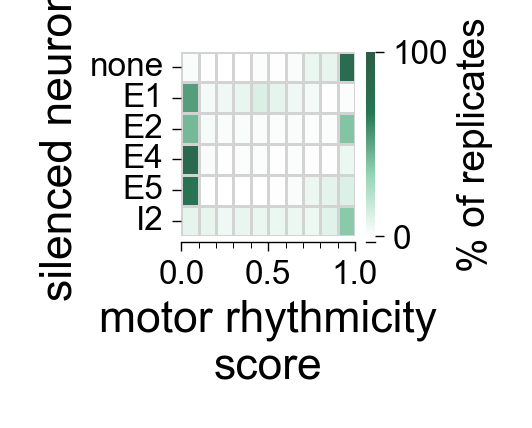

In [4]:
nSims = len(simScore_combined)
histBins = np.linspace(0,np.max(simScore_combined),11)
histBinCenters = (histBins[:-1] + histBins[1:]) / 2
scoreHistDf = pd.DataFrame(index=histBinCenters,columns = simScore_combined.columns)
for col in simScore_combined.columns:
    scoreHistDf[col] = 100*(np.histogram(simScore_combined[col],bins=histBins)[0] / nSims)

xmax = 1.05
nBinsPlotted = len(scoreHistDf[:xmax])
xticklabels = np.round(histBins[np.arange(0,nBinsPlotted+1)],1).astype(str).tolist()
for i in range(len(xticklabels)):
    if i % 5 !=0:
        xticklabels[i]=""

plt.figure(figsize=(0.7,0.6))


# fig.set_figwidth(1.3)
# fig.set_figheight(0.92)

ax = sns.heatmap(scoreHistDf[:xmax].transpose(),cmap=make_palette(mnColor),cbar=True,yticklabels=True,cbar_kws={"ticks":[0,100]},vmax=100,linecolor="lightgray",linewidths=0.5)
cbar = ax.collections[0].colorbar
cbar.set_label("% of replicates",fontsize=7)
sns.despine(offset={"left":2,"bottom":1},left=True)
# ax.set_xticks(np.arange(0,nBinsPlotted+1),xticklabels,rotation=0)

ax.set_xticks(np.arange(0,nBinsPlotted+1,5),np.round(histBins[np.arange(0,nBinsPlotted+1,5)],1))
ax.set_xticks(np.arange(0,nBinsPlotted+1),minor=True)
# ax.grid()
plt.gcf().set_dpi(400)
plt.xlabel("motor rhythmicity\nscore")
plt.ylabel("silenced neuron")

# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# plt.savefig(figFolder+"/mnScoreStackedHeatmaps_smaller.svg",transparent=True)
plt.show()

/tmp/ipykernel_4159973/3839504399.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  scoreHistDf.fillna(0,inplace=True)


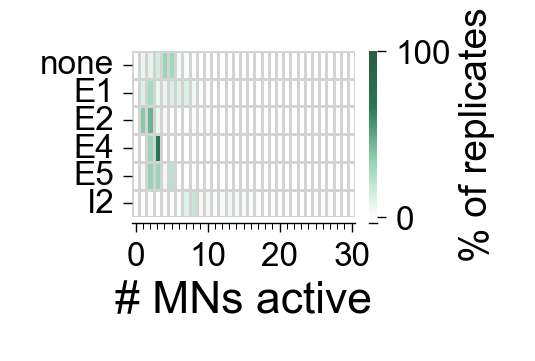

In [6]:
nMnsActiveCounts = nMnsActive_combined.apply(pd.Series.value_counts).fillna(0) #[nActive<=500]
histBins = np.arange(200)
scoreHistDf = pd.DataFrame(index=histBins,columns = nMnsActive_combined.columns)
scoreHistDf.loc[nMnsActiveCounts.index] = nMnsActiveCounts
scoreHistDf.fillna(0,inplace=True)

scoreHistDf = scoreHistDf*100/ nMnsActiveCounts.sum(0) # nSims

xmax = 31
nBinsPlotted = len(scoreHistDf[:xmax])
xticklabels = np.round(histBins[np.arange(0,nBinsPlotted+1)],1).astype(str).tolist()
for i in range(len(xticklabels)):
    if i % 5 !=0:
        xticklabels[i]=""

plt.figure(figsize=(0.9,0.54))

# plt.figure(figsize=(0.7,0.6))


ax = sns.heatmap(scoreHistDf[:xmax].transpose(),cmap=make_palette(mnColor),cbar_kws={"ticks":[0,100]},cbar=True,vmin=0,vmax=100,yticklabels=True,linecolor="lightgray",linewidths=0.25)
cbar = ax.collections[0].colorbar
cbar.set_label("% of replicates",fontsize=7)
sns.despine(offset={"left":2,"bottom":1},left=True)
# ax.set_xticks(np.arange(0,nBinsPlotted+1),xticklabels,rotation=

sns.despine(offset={"left":2,"bottom":1},left=True)
# ax.set_xticks(np.arange(0,nBinsPlotted+1,2),np.round(histBins[np.arange(0,nBinsPlotted+1,2)],1),rotation=45)
ax.set_xticks(np.arange(0.5,nBinsPlotted+.5,10),np.round(histBins[np.arange(0,nBinsPlotted+1,10)],1))
ax.set_xticks(np.arange(0.5,nBinsPlotted+.5,1),minor=True)
plt.gcf().set_dpi(400)
plt.xlabel("# MNs active")


# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# plt.savefig(figFolder+"/activeMnStackedHeatmaps_test.svg",transparent=True)

plt.show()

# FANC 1024x DNb08 activation with CPG IN silencing
data combined from two separate run IDs of the same random seed due to data saving issues (specifically, E2 and E4 silencing had to be rerun)

## load and save first time

In [ ]:
simType = "DNb08_Stim_FANC"
simPathOverall = simType+"/default/run_id=2026041000"
rerunPathOverall = simType+"/default/run_id=2026041001"

figFolder = "../figures/"
figFolder += "DNb08_Stim_Silence_FANC-combined"

In [4]:
removedNrn = ""
simPath = simPathOverall+f'/experiment.removeNeurons=[{removedNrn}],experiment.seed=102'

folder = dataPath + simPath
Rs = sparse.load_npz(folder+f"/ckpt/{simType}_Rs.npz").todense()
params = DictConfig(load_from_yaml(folder+"/logs/run_config.yaml"))

dataset = 0
Rs = Rs[dataset]
nSims = Rs.shape[0]
wTable = pd.read_csv("../"+params.experiment["dfPath"].split("vnc-connectome-sim")[1])
mnData = sort_motor_modules(wTable.loc[wTable["motor module"].notna()])
nActive_intact = pd.Series(index=np.arange(nSims))
nMnsActive = pd.Series(index=np.arange(nSims))
simScore = pd.Series(index=np.arange(nSims))

for i in range(nSims):
    R = Rs[i]
    
    nActive_intact.loc[i] = sum(np.max(R,1)>0.01)
    activeMnsMask = (np.max(R,1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
    nMnsActive.loc[i] = np.sum(activeMnsMask)
    activeMnsMaskPastTransient = (np.max(R[:,250:],1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
    score, _ = compute_oscillation_score(R[:,250:],activeMnsMaskPastTransient)
    simScore.loc[i] = score 

nMnsActive_intact = nMnsActive.copy()
simScore_intact = simScore.copy()

/home/smpuglie/vnc-connectome-sim/src/utils/plot_utils.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neuronData[colName] = pd.Categorical(neuronData[colName],categories=["coxa swing", "coxa stance", "femur/tr extend", "femur/tr flex",


In [6]:
removedNrn = 481
display(wTable.loc[[removedNrn]])
simPath = simPathOverall+f'/experiment.removeNeurons=[{removedNrn}],experiment.seed=102'

folder = dataPath + simPath
Rs = sparse.load_npz(folder+f"/ckpt/{simType}_Rs.npz").todense()
params = DictConfig(load_from_yaml(folder+"/logs/run_config.yaml"))

dataset = 0
Rs = Rs[dataset]
nSims = Rs.shape[0]
wTable = pd.read_csv("../"+params.experiment["dfPath"].split("vnc-connectome-sim")[1])
mnData = sort_motor_modules(wTable.loc[wTable["motor module"].notna()])
nActive_e1silenced = pd.Series(index=np.arange(nSims))
nMnsActive = pd.Series(index=np.arange(nSims))
simScore = pd.Series(index=np.arange(nSims))

for i in range(nSims):
    R = Rs[i]
    
    nActive_e1silenced.loc[i] = sum(np.max(R,1)>0.01)
    activeMnsMask = (np.max(R,1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
    nMnsActive.loc[i] = np.sum(activeMnsMask)
    activeMnsMaskPastTransient = (np.max(R[:,250:],1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
    score, _ = compute_oscillation_score(R[:,250:],activeMnsMaskPastTransient)
    simScore.loc[i] = score
    
nMnsActive_e1silenced = nMnsActive.copy()
simScore_e1silenced = simScore.copy()

,Unnamed: 0,index,id,created,superceded_id,valid,classification_system,cell_type,pt_supervoxel_id,pt_root_id,pt_position_nrn,w_type,sign,w_idx,pt_position_soma,surf_area_um2,motor module,step contribution,class,pt_position
481,481,480.0,2623,2024-01-08 20:53:21.166447+00:00,NaN,t,17A,17A_dorsal_post,72834674820722635,648518346488234782,[23643 92060 1860],17A,1,481,[24584 89736 1773],20291.564974,NaN,NaN,intrinsic neuron,[24584 89736 1773]


/home/smpuglie/vnc-connectome-sim/src/utils/plot_utils.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neuronData[colName] = pd.Categorical(neuronData[colName],categories=["coxa swing", "coxa stance", "femur/tr extend", "femur/tr flex",


In [7]:
removedNrn = 413
display(wTable.loc[[removedNrn]])

simPath = rerunPathOverall+f'/experiment.removeNeurons=[{removedNrn}],experiment.seed=102'

folder = dataPath + simPath
Rs = sparse.load_npz(folder+f"/ckpt/{simType}_Rs.npz").todense()
params = DictConfig(load_from_yaml(folder+"/logs/run_config.yaml"))

dataset = 0
Rs = Rs[dataset]
nSims = Rs.shape[0]
wTable = pd.read_csv("../"+params.experiment["dfPath"].split("vnc-connectome-sim")[1])
mnData = sort_motor_modules(wTable.loc[wTable["motor module"].notna()])
nActive_e2silenced = pd.Series(index=np.arange(nSims))
nMnsActive_e2silenced = pd.Series(index=np.arange(nSims))
simScore_e2silenced = pd.Series(index=np.arange(nSims))


for i in range(nSims):
    R = Rs[i]
    
    nActive_e2silenced.loc[i] = sum(np.max(R,1)>0.01)
    activeMnsMask = (np.max(R,1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
    nMnsActive.loc[i] = np.sum(activeMnsMask)
    activeMnsMaskPastTransient = (np.max(R[:,250:],1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
    score, _ = compute_oscillation_score(R[:,250:],activeMnsMaskPastTransient)
    simScore.loc[i] = score
    
nMnsActive_e2silenced = nMnsActive.copy()
simScore_e2silenced = simScore.copy()

,Unnamed: 0,index,id,created,superceded_id,valid,classification_system,cell_type,pt_supervoxel_id,pt_root_id,pt_position_nrn,w_type,sign,w_idx,pt_position_soma,surf_area_um2,motor module,step contribution,class,pt_position
413,413,412.0,2555,2024-01-08 20:53:20.325803+00:00,NaN,t,16B,16B,72975481296715415,648518346497857270,[27727 93605 2322],TBD,1,413,[32040 85152 2216],12299.931781,NaN,NaN,intrinsic neuron,[32040 85152 2216]


/home/smpuglie/vnc-connectome-sim/src/utils/plot_utils.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neuronData[colName] = pd.Categorical(neuronData[colName],categories=["coxa swing", "coxa stance", "femur/tr extend", "femur/tr flex",


In [8]:
removedNrn = 94
display(wTable.loc[[removedNrn]])

simPath = rerunPathOverall+f'/experiment.removeNeurons=[{removedNrn}],experiment.seed=102'

folder = dataPath + simPath
Rs = sparse.load_npz(folder+f"/ckpt/{simType}_Rs.npz").todense()
params = DictConfig(load_from_yaml(folder+"/logs/run_config.yaml"))

dataset = 0
Rs = Rs[dataset]
nSims = Rs.shape[0]
wTable = pd.read_csv("../"+params.experiment["dfPath"].split("vnc-connectome-sim")[1])
mnData = sort_motor_modules(wTable.loc[wTable["motor module"].notna()])
nActive_e4silenced = pd.Series(index=np.arange(nSims))
nMnsActive_e4silenced = pd.Series(index=np.arange(nSims))
simScore_e4silenced = pd.Series(index=np.arange(nSims))

for i in range(nSims):
    R = Rs[i]
    
    nActive_e4silenced.loc[i] = sum(np.max(R,1)>0.01)
    activeMnsMask = (np.max(R,1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
    nMnsActive_e4silenced.loc[i] = np.sum(activeMnsMask)
    activeMnsMaskPastTransient = (np.max(R[:,250:],1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
    score, _ = compute_oscillation_score(R[:,250:],activeMnsMaskPastTransient)
    simScore_e4silenced.loc[i] = score

nMnsActive_e4silenced = nMnsActive.copy()
simScore_e4silenced = simScore.copy()

,Unnamed: 0,index,id,created,superceded_id,valid,classification_system,cell_type,pt_supervoxel_id,pt_root_id,pt_position_nrn,w_type,sign,w_idx,pt_position_soma,surf_area_um2,motor module,step contribution,class,pt_position
94,94,93.0,2236,2024-01-08 20:53:16.360530+00:00,NaN,t,03A,03A,72624462142676168,648518346494799159,[ 17970 117590 2214],03A,1,94,[ 7880 121944 1748],15837.470552,NaN,NaN,intrinsic neuron,[ 7880 121944 1748]


/home/smpuglie/vnc-connectome-sim/src/utils/plot_utils.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neuronData[colName] = pd.Categorical(neuronData[colName],categories=["coxa swing", "coxa stance", "femur/tr extend", "femur/tr flex",


In [9]:
removedNrn = 177
display(wTable.loc[[removedNrn]])
simPath = simPathOverall+f'/experiment.removeNeurons=[{removedNrn}],experiment.seed=102'

folder = dataPath + simPath
Rs = sparse.load_npz(folder+f"/ckpt/{simType}_Rs.npz").todense()
params = DictConfig(load_from_yaml(folder+"/logs/run_config.yaml"))

dataset = 0
Rs = Rs[dataset]
nSims = Rs.shape[0]
wTable = pd.read_csv("../"+params.experiment["dfPath"].split("vnc-connectome-sim")[1])
mnData = sort_motor_modules(wTable.loc[wTable["motor module"].notna()])
nActive_e5silenced = pd.Series(index=np.arange(nSims))
nMnsActive = pd.Series(index=np.arange(nSims))
simScore = pd.Series(index=np.arange(nSims))

for i in range(nSims):
    R = Rs[i]
    
    nActive_e5silenced.loc[i] = sum(np.max(R,1)>0.01)
    activeMnsMask = (np.max(R,1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
    nMnsActive.loc[i] = np.sum(activeMnsMask)
    activeMnsMaskPastTransient = (np.max(R[:,250:],1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
    score, _ = compute_oscillation_score(R[:,250:],activeMnsMaskPastTransient)
    simScore.loc[i] = score
    
nMnsActive_e5silenced = nMnsActive.copy()
simScore_e5silenced = simScore.copy()

,Unnamed: 0,index,id,created,superceded_id,valid,classification_system,cell_type,pt_supervoxel_id,pt_root_id,pt_position_nrn,w_type,sign,w_idx,pt_position_soma,surf_area_um2,motor module,step contribution,class,pt_position
177,177,176.0,2318,2024-01-08 20:53:17.383938+00:00,NaN,t,08A,08A_ventral_post,72905112552773752,648518346481651905,[25480 92796 2347],TBD,1,177,[29056 82656 1994],25517.580629,NaN,NaN,intrinsic neuron,[29056 82656 1994]


/home/smpuglie/vnc-connectome-sim/src/utils/plot_utils.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neuronData[colName] = pd.Categorical(neuronData[colName],categories=["coxa swing", "coxa stance", "femur/tr extend", "femur/tr flex",


In [10]:
removedNrn = 503
display(wTable.loc[[removedNrn]])
simPath = simPathOverall+f'/experiment.removeNeurons=[{removedNrn}],experiment.seed=102'

folder = dataPath + simPath
Rs = sparse.load_npz(folder+f"/ckpt/{simType}_Rs.npz").todense()
params = DictConfig(load_from_yaml(folder+"/logs/run_config.yaml"))

dataset = 0
Rs = Rs[dataset]
nSims = Rs.shape[0]
wTable = pd.read_csv("../"+params.experiment["dfPath"].split("vnc-connectome-sim")[1])
mnData = sort_motor_modules(wTable.loc[wTable["motor module"].notna()])
nActive_i2silenced = pd.Series(index=np.arange(nSims))
nMnsActive = pd.Series(index=np.arange(nSims))
simScore = pd.Series(index=np.arange(nSims))

for i in range(nSims):
    R = Rs[i]
    
    nActive_i2silenced.loc[i] = sum(np.max(R,1)>0.01)
    activeMnsMask = (np.max(R,1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
    nMnsActive.loc[i] = np.sum(activeMnsMask)
    activeMnsMaskPastTransient = (np.max(R[:,250:],1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
    score, _ = compute_oscillation_score(R[:,250:],activeMnsMaskPastTransient)
    simScore.loc[i] = score
    
nMnsActive_i2silenced = nMnsActive.copy()
simScore_i2silenced = simScore.copy()

,Unnamed: 0,index,id,created,superceded_id,valid,classification_system,cell_type,pt_supervoxel_id,pt_root_id,pt_position_nrn,w_type,sign,w_idx,pt_position_soma,surf_area_um2,motor module,step contribution,class,pt_position
503,503,502.0,2645,2024-01-08 20:53:21.435983+00:00,NaN,t,19A,19A_dorsal_rind,72483380721505294,648518346510192422,[ 13569 107493 1620],19A,-1,503,[ 14448 111920 1387],21716.628557,NaN,NaN,intrinsic neuron,[ 14448 111920 1387]


/home/smpuglie/vnc-connectome-sim/src/utils/plot_utils.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neuronData[colName] = pd.Categorical(neuronData[colName],categories=["coxa swing", "coxa stance", "femur/tr extend", "femur/tr flex",


In [11]:
nActive_combined = pd.concat([nActive_intact,
                                 nActive_e1silenced,
                                 nActive_e2silenced,
                                 nActive_e4silenced,
                                 nActive_e5silenced,
                                 nActive_i2silenced],axis=1).rename(columns={0:"none",1:"E1",2:"E2",3:"E4",4:"E5",5:"I2"})
nMnsActive_combined = pd.concat([nMnsActive_intact,
                                 nMnsActive_e1silenced,
                                 nMnsActive_e2silenced,
                                 nMnsActive_e4silenced,
                                 nMnsActive_e5silenced,
                                 nMnsActive_i2silenced],axis=1).rename(columns={0:"none",1:"E1",2:"E2",3:"E4",4:"E5",5:"I2"})
simScore_combined = pd.concat([simScore_intact,
                               simScore_e1silenced,
                               simScore_e2silenced,
                               simScore_e4silenced,
                               simScore_e5silenced,
                               simScore_i2silenced],axis=1).rename(columns={0:"none",1:"E1",2:"E2",3:"E4",4:"E5",5:"I2"})

if not os.path.exists(figFolder):
    os.makedirs(figFolder)
nActive_combined.to_csv(figFolder+"/nActive.csv")
nMnsActive_combined.to_csv(figFolder+"/nMnsActive.csv")
simScore_combined.to_csv(figFolder+"/scores.csv")

## reload and plot data

In [12]:
nActive_combined = pd.read_csv(figFolder+"/nActive.csv",index_col=0)
nMnsActive_combined = pd.read_csv(figFolder+"/nMnsActive.csv",index_col=0)
simScore_combined = pd.read_csv(figFolder+"/scores.csv",index_col=0)

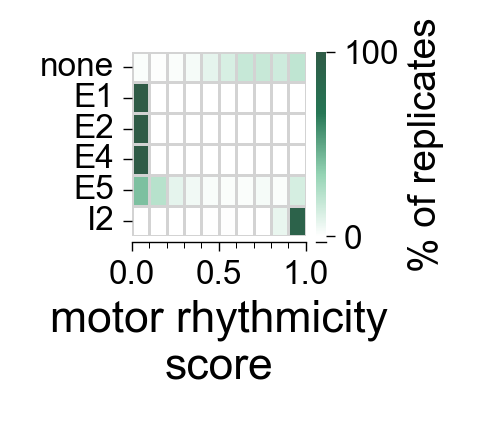

In [13]:
nSims = len(simScore_combined)
histBins = np.linspace(0,np.max(simScore_combined),11)
histBinCenters = (histBins[:-1] + histBins[1:]) / 2
scoreHistDf = pd.DataFrame(index=histBinCenters,columns = simScore_combined.columns)
for col in simScore_combined.columns:
    scoreHistDf[col] = 100*(np.histogram(simScore_combined[col],bins=histBins)[0] / nSims)

xmax = 1.05
nBinsPlotted = len(scoreHistDf[:xmax])
xticklabels = np.round(histBins[np.arange(0,nBinsPlotted+1)],1).astype(str).tolist()
for i in range(len(xticklabels)):
    if i % 5 !=0:
        xticklabels[i]=""

plt.figure(figsize=(0.7,0.6))

ax = sns.heatmap(scoreHistDf[:xmax].transpose(),cmap=make_palette(mnColor),cbar=True,yticklabels=True,cbar_kws={"ticks":[0,100]},vmax=100,linecolor="lightgray",linewidths=0.5)
cbar = ax.collections[0].colorbar
cbar.set_label("% of replicates",fontsize=7)
sns.despine(offset={"left":2,"bottom":1},left=True)
# ax.set_xticks(np.arange(0,nBinsPlotted+1),xticklabels,rotation=0)

ax.set_xticks(np.arange(0,nBinsPlotted+1,5),np.round(histBins[np.arange(0,nBinsPlotted+1,5)],1))
ax.set_xticks(np.arange(0,nBinsPlotted+1),minor=True)
# ax.grid()
plt.gcf().set_dpi(400)
plt.xlabel("motor rhythmicity\nscore")

# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# plt.savefig(figFolder+"/mnScoreStackedHeatmaps.svg",transparent=True)
plt.show()